## 1. Forward Propagation
* Definition: The step-by-step process where input data is fed into the neural network, passed forward through the hidden layers via weighted sums and non-linear activation functions, and ultimately transformed into a prediction at the output layer.
* Use Cases:
    * Generating predictions or inference using a pre-trained neural network model.
    * Computing intermediate layer activations required during the training phase before calculating the loss.
* Pros:
    * Relies primarily on straightforward matrix-vector multiplications, making it exceptionally fast and highly parallelizable on GPUs.
    * Straightforward implementation for real-time model deployment and serving.
* Cons:
    * By itself, forward propagation cannot update weights or learn patterns; it must be paired with a loss function and backpropagation.
    * Deep architectures can face numerical instability (e.g., overflow/underflow) during deep forward passes if activations are unscaled.

### Visualization: Simple Forward Propagation Pass
The code below implements a manual forward propagation pass through a 2-layer neural network using NumPy and visualizes how data transforms across layers.

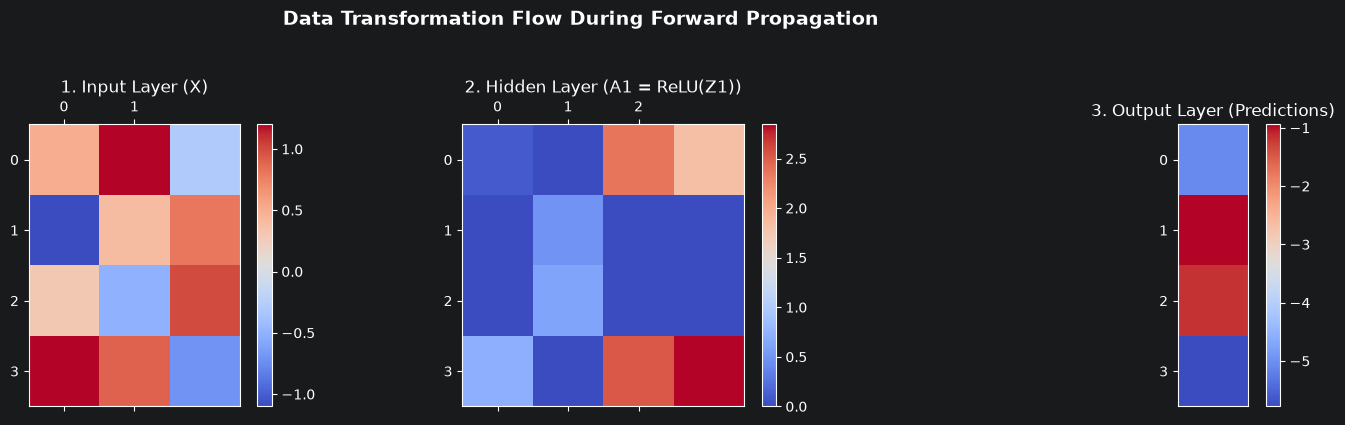

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Set seed and define synthetic input data (batch of 4 samples, 3 features)
np.random.seed(42)
X = np.array([
    [0.5, 1.2, -0.3],
    [-1.1, 0.4, 0.8],
    [0.3, -0.5, 1.0],
    [1.2, 0.9, -0.7]
])

# 2. Define weights and biases for Hidden Layer and Output Layer
# Hidden layer: 3 inputs -> 4 neurons
W1 = np.random.randn(3, 4)
b1 = np.zeros((1, 4))

# Output layer: 4 hidden neurons -> 1 output
W2 = np.random.randn(4, 1)
b2 = np.zeros((1, 1))

# Activation function (ReLU)
def relu(z):
    return np.maximum(0, z)

# 3. Perform Forward Propagation
# Layer 1 (Hidden)
Z1 = np.dot(X, W1) + b1
A1 = relu(Z1)

# Layer 2 (Output)
Z2 = np.dot(A1, W2) + b2
output = Z2  # Linear output for regression

# 4. Visualize data transformation across layers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cax0 = axes[0].matshow(X, cmap='coolwarm')
axes[0].set_title("1. Input Layer (X)")
fig.colorbar(cax0, ax=axes[0], fraction=0.046, pad=0.04)

cax1 = axes[1].matshow(A1, cmap='coolwarm')
axes[1].set_title("2. Hidden Layer (A1 = ReLU(Z1))")
fig.colorbar(cax1, ax=axes[1], fraction=0.046, pad=0.04)

cax2 = axes[2].matshow(output, cmap='coolwarm')
axes[2].set_title("3. Output Layer (Predictions)")
fig.colorbar(cax2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    # int() dönüşümü eklenerek hata giderildi
    ax.set_xticks(range(int(ax.get_xlim()[1])))
    ax.set_yticks(range(4))

plt.suptitle("Data Transformation Flow During Forward Propagation", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()